# Task 1 on **real DiT-XL/2 + ImageNet-256** (by the proposal)

This notebook implements Task 1 **exactly as the proposal requires**: on a
**pretrained DiT-XL/2** (ImageNet-256), **inference-only, no training**
(*"No retraining or weight modification is required; we use publicly available
checkpoints"*). Results are on **real ImageNet classes**, not a toy dataset.

**Implemented:**
- $U_\text{ens}(t,c)$ — ensemble variance across $K$ noise seeds (per-patch),
- $U_\text{attn}(t,\ell)$ — attention entropy from every DiT block,
- logging both across timestep bins × classes → CSV.

$U_\text{route}$ (routing variance) needs a **TREAD DiT-XL/2** checkpoint and is
scaffolded at the end.

> Model: DiT-XL/2 (675M params, 28 blocks, 256 latent tokens), VAE:
> `stabilityai/sd-vae-ft-ema`. Runs on a single ~12 GB GPU.

## 1 · Setup — load the pretrained DiT-XL/2 (no training)

In [1]:
import os, sys, types, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from PIL import Image

# --- make the local DiT repo importable (cloned next to this notebook) ---
REPO = os.getcwd()
DIT_DIR = os.path.join(REPO, "DiT")
assert os.path.isdir(DIT_DIR), f"DiT repo not found at {DIT_DIR} (git clone facebookresearch/DiT)"
sys.path.insert(0, DIT_DIR)

from diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from models import DiT_XL_2

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
image_size, latent_size, patch_size = 256, 32, 2

model = DiT_XL_2(input_size=latent_size).to(device)
ckpt_path = os.path.join(DIT_DIR, "DiT-XL-2-256x256.pt")
state = torch.load(ckpt_path, map_location=device)
state = state.get("ema", state) if isinstance(state, dict) and "ema" in state else state
model.load_state_dict(state)
model.eval()
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema").to(device).eval()
print(f"DiT-XL/2 loaded: {sum(p.numel() for p in model.parameters())/1e6:.0f}M params, "
      f"{len(model.blocks)} blocks, device={device}")

c:\Users\amirn\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DiT-XL/2 loaded: 675M params, 28 blocks, device=cuda


## 2 · These are real ImageNet photos now

Sample a few ImageNet classes with the pretrained model and decode with the VAE.
Class ids follow the standard ImageNet-1k mapping (e.g. 207 = golden retriever,
360 = otter, 387 = lesser panda, 974 = geyser, 88 = macaw).

  0%|          | 0/250 [00:00<?, ?it/s]

100%|██████████| 250/250 [01:39<00:00,  2.51it/s]


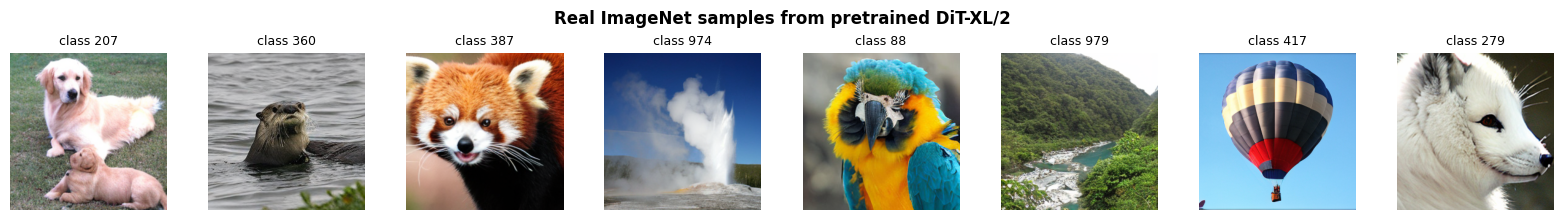

In [2]:
def decode(latents):
    imgs = vae.decode(latents / 0.18215).sample
    imgs = (imgs.clamp(-1, 1) + 1) / 2
    return imgs.permute(0, 2, 3, 1).cpu().numpy()

demo_classes = [207, 360, 387, 974, 88, 979, 417, 279]
diffusion = create_diffusion("250")
n = len(demo_classes)
torch.manual_seed(0)
z = torch.randn(n, 4, latent_size, latent_size, device=device)
z = torch.cat([z, z], 0)
y = torch.tensor(demo_classes + [1000]*n, device=device)   # CFG: cond + null
samples = diffusion.p_sample_loop(model.forward_with_cfg, z.shape, z,
    clip_denoised=False, model_kwargs=dict(y=y, cfg_scale=4.0),
    progress=True, device=device)
samples, _ = samples.chunk(2, 0)
imgs = decode(samples)

fig, axes = plt.subplots(1, n, figsize=(2*n, 2.2))
for ax, im, c in zip(axes, imgs, demo_classes):
    ax.imshow(im); ax.axis("off"); ax.set_title(f"class {c}", fontsize=9)
fig.suptitle("Real ImageNet samples from pretrained DiT-XL/2", fontweight="bold")
plt.tight_layout(); plt.show()

## 3 · $U_\text{ens}(t,c)$ — ensemble variance across seeds

For a class $c$, draw $K$ initial noises, run the **full** reverse path for each,
record $\hat x_0$ at every step, and take **per-patch** variance across seeds
(DiT-XL/2 patch = 2 → 16×16 patch grid). We use `cfg_scale=1.0` (pure conditional)
so the variance reflects the model's own prediction, not the guidance term.

In [3]:
K = 8                    # proposal uses 16; 8 keeps the demo fast (scale up freely)
ENS_STEPS = 100          # sampling steps recorded along the path
patch_size = 2

def x0_to_patch_variance(x0_ens, p=2):
    var = x0_ens.var(dim=0)                      # (C,H,W)
    c, h, w = var.shape
    return var.reshape(c, h//p, p, w//p, p).mean(dim=(0, 2, 4))   # (H//p, W//p)

def run_ensemble(cls, K=8, steps=ENS_STEPS, cfg=1.0, seed_base=0):
    diff = create_diffusion(str(steps))
    ts = [diff.timestep_map[i] for i in range(diff.num_timesteps-1, -1, -1)]
    x0_by_seed = []
    for k in range(K):
        torch.manual_seed(seed_base + k)
        z = torch.randn(1, 4, latent_size, latent_size, device=device)
        zc = torch.cat([z, z], 0)
        y = torch.tensor([cls, 1000], device=device)
        traj = [out["pred_xstart"][:1].cpu() for out in diff.p_sample_loop_progressive(
            model.forward_with_cfg, zc.shape, zc, clip_denoised=False,
            model_kwargs=dict(y=y, cfg_scale=cfg), device=device, progress=False)]
        x0_by_seed.append(torch.stack(traj, 0))            # (T,1,C,H,W)
    ens = torch.stack([x.squeeze(1) for x in x0_by_seed], 0)  # (K,T,C,H,W)
    patch_maps = torch.stack([x0_to_patch_variance(ens[:, t], patch_size)
                              for t in range(ens.shape[1])], 0)  # (T,ph,pw)
    return np.array(ts), patch_maps.numpy()

t0 = time.time()
ts_ens, ens_maps = run_ensemble(207, K=K)
uens_curve = ens_maps.mean(axis=(1, 2))
print(f"class 207: {len(ts_ens)} steps, patch grid {ens_maps.shape[1]}x{ens_maps.shape[2]}, "
      f"U_ens range [{uens_curve.min():.4f}, {uens_curve.max():.4f}]  [{time.time()-t0:.0f}s]")

class 207: 100 steps, patch grid 16x16, U_ens range [0.0133, 0.5157]  [42s]


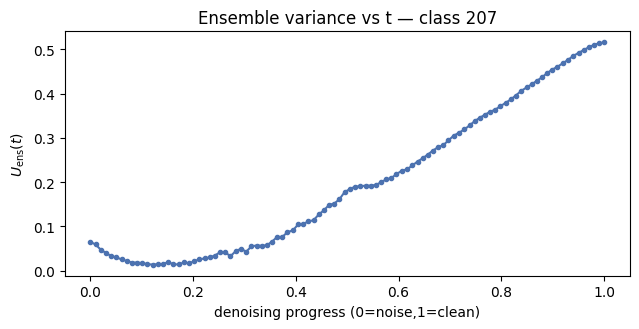

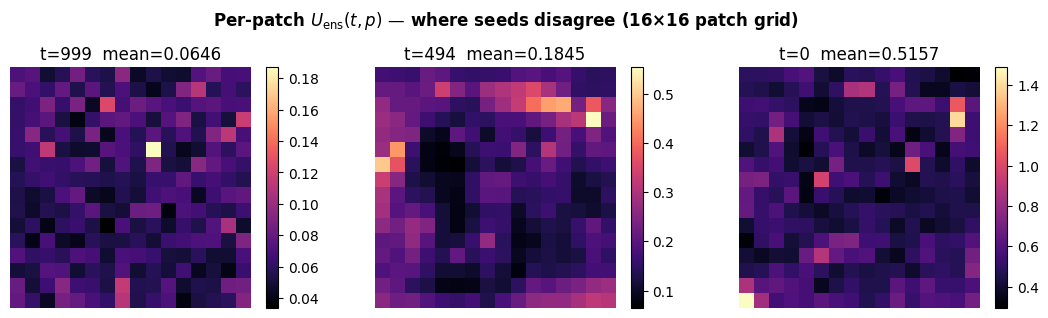

In [4]:
prog = 1.0 - np.array(ts_ens, float)/1000.0
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(prog, uens_curve, color="#4C72B0", marker="o", ms=3)
ax.set_xlabel("denoising progress (0=noise,1=clean)"); ax.set_ylabel(r"$U_\mathrm{ens}(t)$")
ax.set_title("Ensemble variance vs t — class 207")
plt.tight_layout(); plt.show()

idx = [0, len(ens_maps)//2, len(ens_maps)-1]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for axx, ti in zip(axes, idx):
    im = axx.imshow(ens_maps[ti], cmap="magma"); axx.axis("off")
    axx.set_title(f"t={ts_ens[ti]}  mean={ens_maps[ti].mean():.4f}")
    plt.colorbar(im, ax=axx, fraction=0.046)
fig.suptitle(r"Per-patch $U_\mathrm{ens}(t,p)$ — where seeds disagree (16×16 patch grid)",
             fontweight="bold")
plt.tight_layout(); plt.show()

## 4 · $U_\text{attn}(t,\ell)$ — attention entropy

DiT's attention (from `timm`) uses a fused kernel that hides the softmax weights.
We temporarily patch each block's attention `forward` to expose the map, compute
per-query Shannon entropy (max $=\ln N=\ln 256\approx5.55$), then restore it.

In [5]:
_ATTN_ENTROPY = {}
def _capturing_forward(li):
    def forward(self, x, *a, **k):
        B, N, C = x.shape; nh = self.num_heads; hd = C // nh
        qkv = self.qkv(x).reshape(B, N, 3, nh, hd).permute(2, 0, 3, 1, 4)
        q, kk, v = qkv[0], qkv[1], qkv[2]
        if hasattr(self, "q_norm"): q = self.q_norm(q)
        if hasattr(self, "k_norm"): kk = self.k_norm(kk)
        attn = (q * getattr(self, "scale", hd**-0.5)) @ kk.transpose(-2, -1)
        attn = attn.softmax(-1)
        _ATTN_ENTROPY.setdefault(li, []).append(
            -(attn * attn.clamp_min(1e-12).log()).sum(-1).mean().item())
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return self.proj_drop(x) if hasattr(self, "proj_drop") else x
    return forward

def _enable():
    for li, blk in enumerate(model.blocks):
        if not hasattr(blk.attn, "_orig_forward"): blk.attn._orig_forward = blk.attn.forward
        blk.attn.forward = types.MethodType(_capturing_forward(li), blk.attn)
def _disable():
    for blk in model.blocks:
        if hasattr(blk.attn, "_orig_forward"):
            blk.attn.forward = blk.attn._orig_forward; del blk.attn._orig_forward

def run_attention_entropy(cls, steps=100):
    diff = create_diffusion(str(steps)); depth = len(model.blocks)
    ts = [diff.timestep_map[i] for i in range(diff.num_timesteps-1, -1, -1)]
    z = torch.randn(1, 4, latent_size, latent_size, device=device)
    y = torch.tensor([cls], device=device)
    _ATTN_ENTROPY.clear(); per = []
    _enable()
    try:
        for _ in diff.p_sample_loop_progressive(model.forward, z.shape, z,
                clip_denoised=False, model_kwargs=dict(y=y), device=device, progress=False):
            per.append([_ATTN_ENTROPY[li][-1] for li in range(depth)])
    finally:
        _disable(); _ATTN_ENTROPY.clear()
    return np.array(ts), np.array(per)

t0 = time.time()
ts_attn, per_layer = run_attention_entropy(207, steps=100)
print(f"U_attn: shape {per_layer.shape} (steps x depth), "
      f"range [{per_layer.min():.3f}, {per_layer.max():.3f}] nats, ln(256)={np.log(256):.3f} "
      f"[{time.time()-t0:.0f}s]")

U_attn: shape (100, 28) (steps x depth), range [1.729, 5.535] nats, ln(256)=5.545 [3s]


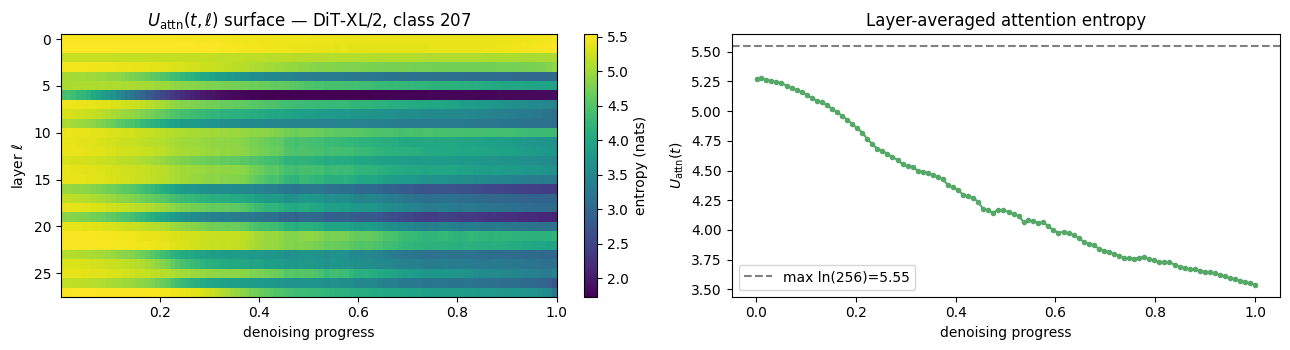

In [6]:
prog = 1.0 - np.array(ts_attn, float)/1000.0
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
im = ax[0].imshow(per_layer.T, aspect="auto", cmap="viridis",
                  extent=[prog[0], prog[-1], len(model.blocks)-0.5, -0.5])
ax[0].set_xlabel("denoising progress"); ax[0].set_ylabel("layer $\\ell$")
ax[0].set_title(r"$U_\mathrm{attn}(t,\ell)$ surface — DiT-XL/2, class 207")
plt.colorbar(im, ax=ax[0], fraction=0.046, label="entropy (nats)")
ax[1].plot(prog, per_layer.mean(1), color="#55A868", marker="o", ms=3)
ax[1].axhline(np.log(256), color="grey", ls="--", label=f"max ln(256)={np.log(256):.2f}")
ax[1].set_xlabel("denoising progress"); ax[1].set_ylabel(r"$U_\mathrm{attn}(t)$")
ax[1].set_title("Layer-averaged attention entropy"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5 · Log both proxies across timestep bins × classes (Task 1.4)

Runs $U_\text{ens}$ and $U_\text{attn}$ for a panel of ImageNet classes, bins them
onto a common timestep axis, and saves a tidy CSV. Expand `CLASS_PANEL` to the 50
proposal classes and raise `K`/steps for the full run.

In [7]:
CLASS_PANEL = [207, 360, 974]     # small demo panel; extend to your 50 classes
N_BINS, LOG_STEPS = 20, 100

def bin_series(t_vals, y_vals, n_bins=N_BINS, t_max=1000):
    t_vals = np.asarray(t_vals, float); y_vals = np.asarray(y_vals, float)
    edges = np.linspace(0, t_max, n_bins+1)
    idx = np.clip(np.digitize(t_vals, edges)-1, 0, n_bins-1)
    out = np.full(n_bins, np.nan)
    for b in range(n_bins):
        if (idx == b).any(): out[b] = y_vals[idx == b].mean()
    return out, ((edges[:-1]+edges[1:])/2).astype(int)

records = []
for c in CLASS_PANEL:
    ts_e, maps = run_ensemble(c, K=K, steps=LOG_STEPS)
    b_ens, centres = bin_series(ts_e, maps.mean(axis=(1, 2)))
    ts_a, pl = run_attention_entropy(c, steps=LOG_STEPS)
    b_attn, _ = bin_series(ts_a, pl.mean(1))
    for k in range(N_BINS):
        records.append({"class_id": c, "bin": k, "t_centre": int(centres[k]),
                        "U_ens": b_ens[k], "U_attn": b_attn[k]})
    print(f"class {c}: logged {N_BINS} bins")

log_df = pd.DataFrame(records)
log_df.to_csv(os.path.join(REPO, "task1_uncertainty_log_imagenet.csv"), index=False)
print("saved -> task1_uncertainty_log_imagenet.csv", log_df.shape)
log_df.head()

class 207: logged 20 bins
class 360: logged 20 bins
class 974: logged 20 bins
saved -> task1_uncertainty_log_imagenet.csv (60, 5)


,class_id,bin,t_centre,U_ens,U_attn
0,207,0,25,0.508622,3.562583
1,207,1,75,0.476332,3.620697
2,207,2,125,0.437616,3.665642
3,207,3,175,0.396330,3.716609
4,207,4,225,0.358360,3.759020


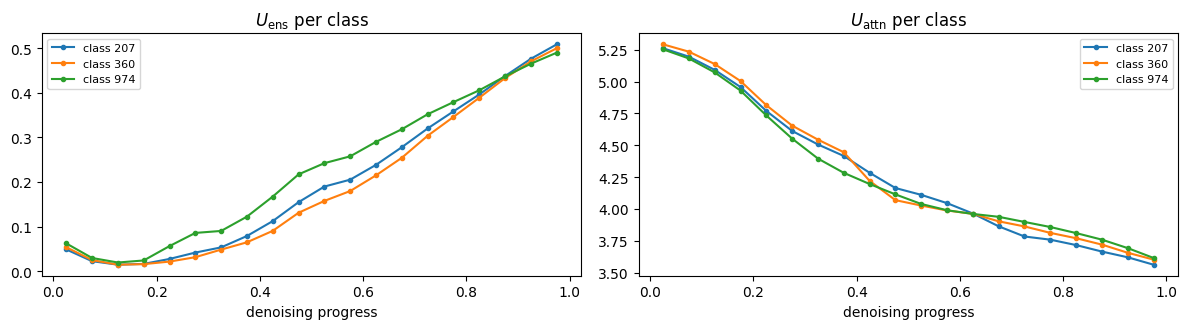

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for c in CLASS_PANEL:
    sub = log_df[log_df.class_id == c].sort_values("bin")
    p = 1.0 - sub["t_centre"].values/1000.0
    ax[0].plot(p, sub["U_ens"], marker="o", ms=3, label=f"class {c}")
    ax[1].plot(p, sub["U_attn"], marker="o", ms=3, label=f"class {c}")
ax[0].set_title(r"$U_\mathrm{ens}$ per class"); ax[1].set_title(r"$U_\mathrm{attn}$ per class")
for a in ax: a.set_xlabel("denoising progress"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6 · $U_\text{route}$ — routing variance (needs TREAD checkpoint)

Routing variance is the **epistemic** proxy and is only legitimate on a **TREAD
DiT-XL/2** (trained with per-token stochastic routing). It cannot be computed on
this vanilla DiT-XL/2. Once the TREAD checkpoint + repo are available:

1. load the TREAD model and its routing API (span $i\approx2,\ j\approx B-4$, the
   training selection rate),
2. fix seed $z$, run the reference full path, and at each $x_t$ draw $M=16$ routes,
3. take per-patch variance of $\hat x_0$ across routes,
4. run the **route-sanity** check (routed vs full-path final sample).

Reference implementation: `notebooks/duq/proxies.py` → `routing_variance`,
`route_sanity` (port by swapping in the TREAD routed forward).

---
### Task 1 status (real DiT-XL/2)
| Sub-task | Status |
|----------|--------|
| 1 · $U_\text{ens}$ | ✅ real ImageNet, per-patch + profile |
| 3 · $U_\text{attn}$ | ✅ real ImageNet, surface + curve |
| 4 · logging | ✅ CSV over class × bin |
| 2 · $U_\text{route}$ | ⏳ needs TREAD DiT-XL/2 checkpoint |